In [1]:
#importing the  libraries
import numpy as np
import pandas as pd
import seaborn as sns
import os 
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.layers import Dense,Input,Dropout,Flatten,GlobalAveragePooling2D,Conv2D,BatchNormalization,Activation,MaxPooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

In [2]:
#Defining the path input
picture_size = 36
folder_path = "C:\\Users\\Manohar\\OneDrive\\Pictures\\Manu"

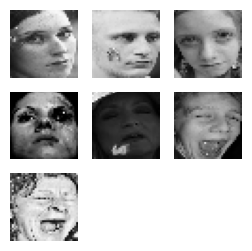

In [3]:
expression = "sadness"

plt.figure(figsize=(3,3))

for i in range(1,8):
    img_dir=os.path.join(folder_path,"train",expression)
    img_files=os.listdir(img_dir)
    img_path=os.path.join(img_dir,img_files[i])


    img = load_img(img_path, target_size=(picture_size, picture_size))
    plt.subplot(3,3,i)
    plt.imshow(img)
    plt.axis("off")
plt.show()


In [4]:
batch_size = 128

datagen_train = ImageDataGenerator()
datagen_val = ImageDataGenerator()

train_set = datagen_train.flow_from_directory(
    os.path.join(folder_path, "train"),
    target_size=(picture_size, picture_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

validation_set = datagen_val.flow_from_directory(
    os.path.join(folder_path, "validation"),
    target_size=(picture_size, picture_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print("Train classes:", train_set.class_indices)
print("Validation classes:", validation_set.class_indices)
if train_set.num_classes != validation_set.num_classes:
    raise ValueError(f"Number of classes mismatch: train={train_set.num_classes}, validation={validation_set.num_classes}")


Found 5558 images belonging to 8 classes.
Found 5558 images belonging to 8 classes.
Train classes: {'anger': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happiness': 4, 'neutrality': 5, 'sadness': 6, 'surprise': 7}
Validation classes: {'anger': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happiness': 4, 'neutrality': 5, 'sadness': 6, 'surprise': 7}


In [5]:
#model building

# determine classes from the training generator
no_of_classes = train_set.num_classes
print("Number of classes:", no_of_classes)

model = Sequential()

#1st cnn layer
model.add(Conv2D(64,(3,3),padding="same",input_shape=(picture_size,picture_size,1)))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

#2nd cnn layer
model.add(Conv2D(128,(3,3),padding="same"))
model.add(BatchNormalization()) 
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

#3rd cnn layer
model.add(Conv2D(256,(3,3),padding="same")) 
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

#4th cnn layer
model.add(Conv2D(256,(3,3),padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))       
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

#fully connected layer
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation("relu"))       
model.add(Dropout(0.3))

model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.3))

model.add(Dense(no_of_classes,activation="softmax"))
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,loss="categorical_crossentropy",metrics=["accuracy"])
model.summary()


Number of classes: 8


c:\Users\Manohar\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 36, 36, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 36, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 9, 9, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,02

 Total params: 1,363,720 (5.20 MB)

 Trainable params: 1,360,776 (5.19 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [6]:
#importing the tensor flow library and packages
#from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

#callbacks
checkpoint = ModelCheckpoint("./model.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

early_stopping = EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=3, 
    verbose=1, 
    restore_best_weights=True
    )

reduce_learningrate = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2, 
    patience=3, 
    verbose=1, 
    min_delta=0.0001)

callbacks_list =[early_stopping, reduce_learningrate, checkpoint]

#training the  setup
epochs = 20

#compile the model with the correct optimizer agruments
model.compile(
    loss = "categorical_crossentropy",
    optimizer = Adam(learning_rate=0.001),
    metrics = ["accuracy"]
)



In [7]:
history = model.fit(
    train_set,
    validation_data=validation_set,
    epochs=epochs,
    callbacks=callbacks_list
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1778 - loss: 2.3535
Epoch 1: val_accuracy improved from None to 0.13440, saving model to ./model.h5



Epoch 1: finished saving model to ./model.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 493s 11s/step - accuracy: 0.2053 - loss: 2.2270 - val_accuracy: 0.1344 - val_loss: 3.4467 - learning_rate: 0.0010
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 975ms/step - accuracy: 0.2557 - loss: 2.0568
Epoch 2: val_accuracy did not improve from 0.13440
44/44 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.2742 - loss: 2.0120 - val_accuracy: 0.1168 - val_loss: 3.6391 - learning_rate: 0.0010
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 736ms/step - accuracy: 0.3249 - loss: 1.8592
Epoch 3: val_accuracy improved from 0.13440 to 0.34599, saving model to ./model.h5



Epoch 3: finished saving model to ./model.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.3345 - loss: 1.8491 - val_accuracy: 0.3460 - val_loss: 1.9152 - learning_rate: 0.0010
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3533 - loss: 1.7704
Epoch 4: val_accuracy improved from 0.34599 to 0.41238, saving model to ./model.h5



Epoch 4: finished saving model to ./model.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 165s 4s/step - accuracy: 0.3607 - loss: 1.7574 - val_accuracy: 0.4124 - val_loss: 1.5984 - learning_rate: 0.0010
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.3942 - loss: 1.6661
Epoch 5: val_accuracy improved from 0.41238 to 0.41994, saving model to ./model.h5



Epoch 5: finished saving model to ./model.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.3996 - loss: 1.6562 - val_accuracy: 0.4199 - val_loss: 1.6561 - learning_rate: 0.0010
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.4238 - loss: 1.5753
Epoch 6: val_accuracy improved from 0.41994 to 0.43631, saving model to ./model.h5



Epoch 6: finished saving model to ./model.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 658ms/step - accuracy: 0.4190 - loss: 1.6017 - val_accuracy: 0.4363 - val_loss: 1.4749 - learning_rate: 0.0010
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.4440 - loss: 1.5296
Epoch 7: val_accuracy improved from 0.43631 to 0.50774, saving model to ./model.h5



Epoch 7: finished saving model to ./model.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 689ms/step - accuracy: 0.4392 - loss: 1.5408 - val_accuracy: 0.5077 - val_loss: 1.3440 - learning_rate: 0.0010
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.4663 - loss: 1.4735
Epoch 8: val_accuracy improved from 0.50774 to 0.50846, saving model to ./model.h5



Epoch 8: finished saving model to ./model.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.4592 - loss: 1.4831 - val_accuracy: 0.5085 - val_loss: 1.3433 - learning_rate: 0.0010
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4692 - loss: 1.4352
Epoch 9: val_accuracy did not improve from 0.50846
44/44 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.4696 - loss: 1.4460 - val_accuracy: 0.4847 - val_loss: 1.3676 - learning_rate: 0.0010
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4694 - loss: 1.4174
Epoch 10: val_accuracy did not improve from 0.50846
44/44 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.4858 - loss: 1.3864 - val_accuracy: 0.5004 - val_loss: 1.3137 - learning_rate: 0.0010
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.5165 - loss: 1.3306
Epoch 11: val_accuracy did not improve from 0.50846
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 581ms/step - accuracy: 0.5076 - loss: 1.3435 - val_accuracy: 0.4761 - val_loss: 1.3278 - learni


Epoch 12: finished saving model to ./model.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 620ms/step - accuracy: 0.5128 - loss: 1.3080 - val_accuracy: 0.5367 - val_loss: 1.2699 - learning_rate: 0.0010
Epoch 13/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.5344 - loss: 1.2550
Epoch 13: val_accuracy improved from 0.53670 to 0.57413, saving model to ./model.h5



Epoch 13: finished saving model to ./model.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 615ms/step - accuracy: 0.5293 - loss: 1.2723 - val_accuracy: 0.5741 - val_loss: 1.1274 - learning_rate: 0.0010
Epoch 14/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.5297 - loss: 1.2619
Epoch 14: val_accuracy did not improve from 0.57413
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 631ms/step - accuracy: 0.5385 - loss: 1.2477 - val_accuracy: 0.5369 - val_loss: 1.2103 - learning_rate: 0.0010
Epoch 15/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.5667 - loss: 1.1754
Epoch 15: val_accuracy did not improve from 0.57413
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 637ms/step - accuracy: 0.5551 - loss: 1.2018 - val_accuracy: 0.5398 - val_loss: 1.2128 - learning_rate: 0.0010
Epoch 16/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.5727 - loss: 1.1551
Epoch 16: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 16: val_accuracy did not improve from 0.57413
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 

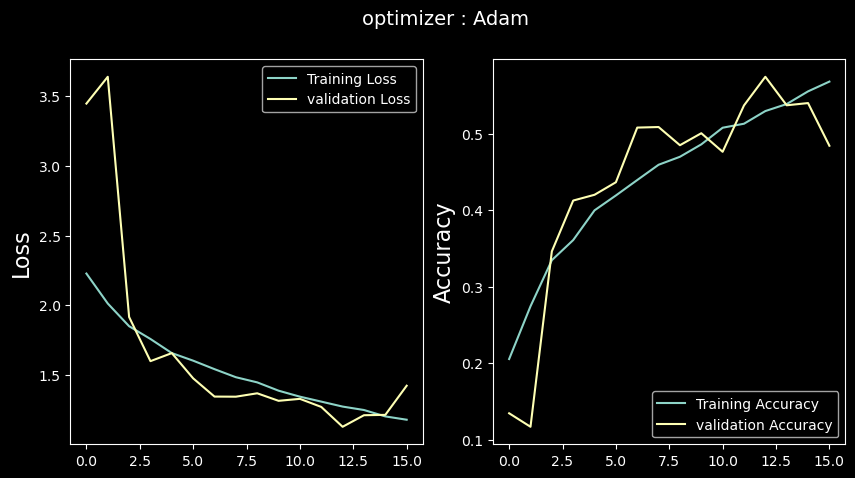

In [8]:
#plotting graphs for accuracy and loss

import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.figure(figsize = (10,5))


#loss plot
plt.subplot(1,2,1)
plt.suptitle('optimizer : Adam', fontsize=14)
plt.ylabel('Loss',fontsize = 16)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'],label='validation Loss')
plt.legend(loc ='upper right')

#Accuracy plot
plt.subplot(1,2,2)
plt.ylabel('Accuracy',fontsize = 16)
plt.plot(history.history['accuracy'],label ='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')
plt.legend(loc ='lower right')

plt.show()

In [9]:
#prediction
img_path = r"C:\Users\Manohar\OneDrive\Pictures\Manu\train\happiness\2Q__ (8)_face.png"

# use the same `picture_size` as the model's input
img = load_img(img_path, target_size=(picture_size, picture_size), color_mode="grayscale")

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)

class_labels = list(train_set.class_indices.keys())
print("predicted class:", class_labels[predicted_class[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
predicted class: sadness


In [10]:
# Build compiled metrics by evaluating the model on the validation set
try:
    print("Evaluating model on validation set to build metrics...")
    results = model.evaluate(validation_set, verbose=1)
    if isinstance(results, (list, tuple)) and len(results) >= 2:
        print(f"Validation loss: {results[0]:.4f}, Validation accuracy: {results[1]:.4f}")
    else:
        print("Evaluation results:", results)
except Exception as e:
    print("Evaluation failed:", e)


Evaluating model on validation set to build metrics...
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 207ms/step - accuracy: 0.5741 - loss: 1.1274
Validation loss: 1.1274, Validation accuracy: 0.5741


In [11]:
# use webcam for the prediction
%pip install opencv-python -q
import cv2
from tensorflow.keras.models import load_model

# load the trained model
model = load_model("model.h5")

emotion_labels = [
    "angry",
    "fear",
    "disgust",
    "happiness",
    "sadness",
    "neutral",
    "contempt"
]

# correct CascadeClassifier path and name
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_gray = cv2.resize(roi_gray, (picture_size, picture_size))
        roi = roi_gray.astype("float") / 255.0
        # add channel and batch dimensions
        roi = np.expand_dims(roi, axis=-1)
        roi = np.expand_dims(roi, axis=0)

        # predict and get emotion
        prediction = model.predict(roi)
        emotion_index = np.argmax(prediction)
        emotion = emotion_labels[emotion_index]

        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(frame, emotion, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    cv2.imshow("Real Time Emotion Detection", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# release and cleanup
cap.release()
cv2.destroyAllWindows()

Note: you may need to restart the kernel to use updated packages.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━